# Data Preparation & Initialization

### Set Gobal Seed

In [1]:
Seed = 1

### Import Data

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed_data/packet-data/for_data.csv")

df.head()

,channel_10_count,channel_10_mean,channel_10_var,channel_1_count,channel_1_mean,channel_1_var,channel_30_count,channel_30_mean,channel_30_var,channel_5_count,...,tcp_window_size,time_since_previously_displayed_frame,ttl,uri_depth,uri_length,uri_param_count,uri_special_chars,var_p,id,label
0,-1.581537,-0.842522,0.771697,-1.311927,-0.811524,-1.431741,-1.826406,-0.842090,0.786877,-1.494342,...,-1.432806,0.011012,-0.530232,-0.090281,-0.095711,-0.079311,-0.057043,-0.803359,0,benign
1,-0.263427,-0.762558,-0.361727,-0.341756,-0.750308,-0.064285,0.143060,-0.774783,-0.462200,-0.454379,...,0.907656,0.002189,-0.579482,-0.090281,-0.095711,-0.079311,-0.057043,-0.639181,1,benign
2,-0.807535,-0.435740,0.300755,-0.720894,-0.442117,0.570058,-0.589184,-0.439128,0.273772,-0.663654,...,0.290262,-0.011846,-0.530232,-0.090281,-0.095711,-0.079311,-0.057043,-0.670437,2,benign
3,-0.191515,-0.885359,-1.022789,-1.050391,-0.784083,-0.054231,-0.034582,-0.866827,-0.443953,-0.233760,...,-1.432806,-0.011856,-1.318230,-0.090281,-0.095711,-0.079311,-0.057043,-0.042758,4,benign
4,0.192499,-0.834817,-1.149986,-0.417729,-0.797050,-0.481221,0.047961,-0.832411,-1.139740,0.051862,...,-1.432806,0.030819,-0.530232,-0.090281,-0.095711,-0.079311,-0.057043,-1.253344,5,benign


### Drop Variables Not Used
- Drop "id" column

In [3]:
# Preserve IDs for linking Phase 2 alerts to Phase 3 flow records.
packet_ids = df["id"].copy() if "id" in df.columns else pd.Series(df.index)

# ID is an identifier, not a behavioral feature.
df = df.drop(columns=["id"], errors="ignore")

df.head()

,channel_10_count,channel_10_mean,channel_10_var,channel_1_count,channel_1_mean,channel_1_var,channel_30_count,channel_30_mean,channel_30_var,channel_5_count,...,sum_p,tcp_window_size,time_since_previously_displayed_frame,ttl,uri_depth,uri_length,uri_param_count,uri_special_chars,var_p,label
0,-1.581537,-0.842522,0.771697,-1.311927,-0.811524,-1.431741,-1.826406,-0.842090,0.786877,-1.494342,...,-0.779439,-1.432806,0.011012,-0.530232,-0.090281,-0.095711,-0.079311,-0.057043,-0.803359,benign
1,-0.263427,-0.762558,-0.361727,-0.341756,-0.750308,-0.064285,0.143060,-0.774783,-0.462200,-0.454379,...,-0.558099,0.907656,0.002189,-0.579482,-0.090281,-0.095711,-0.079311,-0.057043,-0.639181,benign
2,-0.807535,-0.435740,0.300755,-0.720894,-0.442117,0.570058,-0.589184,-0.439128,0.273772,-0.663654,...,-0.900192,0.290262,-0.011846,-0.530232,-0.090281,-0.095711,-0.079311,-0.057043,-0.670437,benign
3,-0.191515,-0.885359,-1.022789,-1.050391,-0.784083,-0.054231,-0.034582,-0.866827,-0.443953,-0.233760,...,-0.379196,-1.432806,-0.011856,-1.318230,-0.090281,-0.095711,-0.079311,-0.057043,-0.042758,benign
4,0.192499,-0.834817,-1.149986,-0.417729,-0.797050,-0.481221,0.047961,-0.832411,-1.139740,0.051862,...,-0.880612,-1.432806,0.030819,-0.530232,-0.090281,-0.095711,-0.079311,-0.057043,-1.253344,benign


### Create Data Matrix and Label Vector

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate labels for stratification and evaluation; labels are never passed to fit().
X = df.drop(columns=["label"]).to_numpy()
y = df["label"].to_numpy()

print("Data matrix shape:", X.shape)
print("Label vector shape:", y.shape)

row_indices = np.arange(X.shape[0])
X_train, X_remaining, y_train, y_remaining, index_train, index_remaining = train_test_split(
    X, y, row_indices, test_size=0.4, stratify=y, random_state=Seed
)
X_validation, X_test, y_validation, y_test, index_validation, index_test = train_test_split(
    X_remaining,
    y_remaining,
    index_remaining,
    test_size=0.5,
    stratify=y_remaining,
    random_state=Seed,
)

# Fit preprocessing only on the training partition.
phase2_scaler = StandardScaler()
X_train_scaled = phase2_scaler.fit_transform(X_train)
X_validation_scaled = phase2_scaler.transform(X_validation)
X_test_scaled = phase2_scaler.transform(X_test)

# Phase 2 models learn the normal profile only from benign training rows.
benign_train_mask = y_train == "benign"

print("Train/validation/test sizes:", X_train.shape[0], X_validation.shape[0], X_test.shape[0])
print("Benign-only training rows:", benign_train_mask.sum())
print("Attack rows excluded from model fitting:", (~benign_train_mask).sum())
print("Labels are retained only for analysis and model selection, not passed as features.")

Data matrix shape: (195940, 136)
Label vector shape: (195940,)


Train/validation/test sizes: 117564 39188 39188
Benign-only training rows: 114000
Attack rows excluded from model fitting: 3564
Labels are retained only for analysis and model selection, not passed as features.


# K-means (high-recall alert generator)

### K-means Hyperparameters Tuning
- Hyperparameters:
    - K: number of clusters used to represent benign behaviour
    - Threshold_percentile: distance cutoff for classifying a sample as anomalous

- Model selection uses validation results 
    - recall >= 0.9 and FPR <= 0.15
    - if non qualify
    - keep configuration with FPR <= 0.15


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                             roc_auc_score, average_precision_score)

k_values = [2, 4, 6, 8, 10, 15, 20, 40, 50, 60, 80, 100]
threshold_percentiles = [80, 85, 90, 92, 95, 97, 99]

# Fit K-means only on benign training features; labels are used only to select rows and evaluate.
X_kmeans_train = X_train_scaled[benign_train_mask]
X_evaluation = X_validation_scaled
y_evaluation = y_validation
y_attack = y_validation[y_validation != "benign"]
true_attack = y_evaluation != "benign"

models = {}
thresholds = {}
inertias = []
kmeans_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=5,
        random_state=Seed,
    )
    model.fit(X_kmeans_train)

    # A sample is anomalous when its nearest-centroid distance exceeds
    # the chosen percentile of benign-only training distances.
    training_distances = model.transform(X_kmeans_train).min(axis=1)
    evaluation_distances = model.transform(X_evaluation).min(axis=1)

    models[k] = model
    inertias.append(model.inertia_)

    for percentile in threshold_percentiles:
        threshold = np.percentile(training_distances, percentile)
        predicted_attack = evaluation_distances > threshold

        precision = precision_score(true_attack, predicted_attack, zero_division=0)
        recall = recall_score(true_attack, predicted_attack, zero_division=0)
        f1 = f1_score(true_attack, predicted_attack, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(
            true_attack, predicted_attack, labels=[False, True]
        ).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        fnr = fn / (fn + tp) if (fn + tp) else 0.0

        thresholds[(k, percentile)] = threshold
        kmeans_results.append({
            "k": k,
            "threshold_percentile": percentile,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "fpr": fpr,
            "fnr": fnr,
        })

        print(
            f"k={k}, percentile={percentile}: Precision={precision:.4f}, "
            f"Recall={recall:.4f}, F1={f1:.4f}"
        )
        print("  Confusion matrix [[TP, FP], [FN, TN]]:")
        print("  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]")
        print(np.array([[tp, fp], [fn, tn]]))
        for attack in sorted(np.unique(y_attack)):
            attack_mask = y_evaluation == attack
            detection_rate = predicted_attack[attack_mask].mean()
            print(f"  {attack} detection rate: {detection_rate:.4f}")

kmeans_results_df = pd.DataFrame(kmeans_results)
display(
    kmeans_results_df.sort_values("fnr", ascending=True).reset_index(drop=True)
)

# Prefer high recall for Phase 2, while limiting validation false alarms.
eligible_kmeans = kmeans_results_df[
    (kmeans_results_df["recall"] >= 0.90) & (kmeans_results_df["fpr"] <= 0.15)
]
if eligible_kmeans.empty:
    eligible_kmeans = kmeans_results_df[kmeans_results_df["fpr"] <= 0.15]
if eligible_kmeans.empty:
    eligible_kmeans = kmeans_results_df
best_kmeans_config = eligible_kmeans.sort_values(
    ["fnr", "fpr", "f1"], ascending=[True, True, False]
).iloc[0]

best_k = int(best_kmeans_config["k"])
best_kmeans_percentile = int(best_kmeans_config["threshold_percentile"])
best_kmeans_model = models[best_k]
best_kmeans_threshold = thresholds[(best_k, best_kmeans_percentile)]
kmeans_test_scores = best_kmeans_model.transform(X_test_scaled).min(axis=1)
kmeans_test_predictions = kmeans_test_scores > best_kmeans_threshold
kmeans_test_truth = y_test != "benign"
kmeans_test_precision = precision_score(kmeans_test_truth, kmeans_test_predictions, zero_division=0)
kmeans_test_recall = recall_score(kmeans_test_truth, kmeans_test_predictions, zero_division=0)
kmeans_test_f1 = f1_score(kmeans_test_truth, kmeans_test_predictions, zero_division=0)
kmeans_tn, kmeans_fp, kmeans_fn, kmeans_tp = confusion_matrix(
    kmeans_test_truth, kmeans_test_predictions, labels=[False, True]
).ravel()
kmeans_test_fpr = kmeans_fp / (kmeans_fp + kmeans_tn)
kmeans_test_fnr = kmeans_fn / (kmeans_fn + kmeans_tp)
kmeans_test_roc_auc = roc_auc_score(kmeans_test_truth, kmeans_test_scores)
kmeans_test_pr_auc = average_precision_score(kmeans_test_truth, kmeans_test_scores)
print(
    f"Final K-means test: k={best_k}, percentile={best_kmeans_percentile}, "
    f"Precision={kmeans_test_precision:.4f}, Recall={kmeans_test_recall:.4f}, "
    f"F1={kmeans_test_f1:.4f}, FPR={kmeans_test_fpr:.4f}, "
    f"FNR={kmeans_test_fnr:.4f}, ROC-AUC={kmeans_test_roc_auc:.4f}, "
    f"PR-AUC={kmeans_test_pr_auc:.4f}"
)
print(np.array([[kmeans_tp, kmeans_fp], [kmeans_fn, kmeans_tn]]))
for attack in sorted(np.unique(y_test[y_test != "benign"])):
    attack_mask = y_test == attack
    print(f"  {attack} detection rate: {kmeans_test_predictions[attack_mask].mean():.4f}")

kmeans_alerts_df = pd.DataFrame({
    "packet_id": packet_ids.iloc[index_test].to_numpy(),
    "true_label": y_test,
    "anomaly_score": kmeans_test_scores,
    "alert": kmeans_test_predictions,
})
kmeans_alerts_df = kmeans_alerts_df[kmeans_alerts_df["alert"]].reset_index(drop=True)

k=2, percentile=80: Precision=0.1034, Recall=0.7365, F1=0.1814
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  875  7585]
 [  313 30415]]
  brute_force detection rate: 0.7300
  ddos detection rate: 0.9831
  dns_spoofing detection rate: 0.4748
  dos detection rate: 0.9580
  xss detection rate: 0.5378
k=2, percentile=85: Precision=0.1241, Recall=0.6818, F1=0.2100
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  810  5717]
 [  378 32283]]
  brute_force detection rate: 0.6751
  ddos detection rate: 0.9831
  dns_spoofing detection rate: 0.3571
  dos detection rate: 0.9244
  xss detection rate: 0.4706
k=2, percentile=90: Precision=0.1547, Recall=0.5884, F1=0.2450
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  699  3818]
 [  489 34182]]
  brute_force detection rate: 0.5148
  ddos detection rate: 0.

k=4, percentile=80: Precision=0.1142, Recall=0.8350, F1=0.2009
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  992  7696]
 [  196 30304]]
  brute_force detection rate: 0.9156
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.5420
  dos detection rate: 1.0000
  xss detection rate: 0.7185
k=4, percentile=85: Precision=0.1411, Recall=0.7862, F1=0.2392
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  934  5686]
 [  254 32314]]
  brute_force detection rate: 0.8481
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.4706
  dos detection rate: 1.0000
  xss detection rate: 0.6134
k=4, percentile=90: Precision=0.1798, Recall=0.7037, F1=0.2864
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  836  3813]
 [  352 34187]]
  brute_force detection rate: 0.6793
  ddos detection rate: 1.

k=6, percentile=80: Precision=0.1189, Recall=0.8864, F1=0.2097
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1053  7803]
 [  135 30197]]
  brute_force detection rate: 0.9409
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.6429
  dos detection rate: 1.0000
  xss detection rate: 0.8487
k=6, percentile=85: Precision=0.1452, Recall=0.8350, F1=0.2474
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  992  5838]
 [  196 32162]]
  brute_force detection rate: 0.8819
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.5672
  dos detection rate: 1.0000
  xss detection rate: 0.7269
k=6, percentile=90: Precision=0.1900, Recall=0.7710, F1=0.3048
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  916  3906]
 [  272 34094]]
  brute_force detection rate: 0.7300
  ddos detection rate: 1.

k=8, percentile=80: Precision=0.1198, Recall=0.8897, F1=0.2112
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1057  7764]
 [  131 30236]]
  brute_force detection rate: 0.9536
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.6261
  dos detection rate: 1.0000
  xss detection rate: 0.8697
k=8, percentile=85: Precision=0.1470, Recall=0.8392, F1=0.2501
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  997  5787]
 [  191 32213]]
  brute_force detection rate: 0.9072
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.5462
  dos detection rate: 1.0000
  xss detection rate: 0.7437
k=8, percentile=90: Precision=0.1879, Recall=0.7500, F1=0.3005
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  891  3852]
 [  297 34148]]
  brute_force detection rate: 0.7004
  ddos detection rate: 1.

k=10, percentile=80: Precision=0.1187, Recall=0.8897, F1=0.2094
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1057  7850]
 [  131 30150]]
  brute_force detection rate: 0.9325
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.6639
  dos detection rate: 1.0000
  xss detection rate: 0.8529
k=10, percentile=85: Precision=0.1470, Recall=0.8519, F1=0.2507
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1012  5872]
 [  176 32128]]
  brute_force detection rate: 0.8987
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.5882
  dos detection rate: 1.0000
  xss detection rate: 0.7731
k=10, percentile=90: Precision=0.1980, Recall=0.8157, F1=0.3186
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[  969  3925]
 [  219 34075]]
  brute_force detection rate: 0.8692
  ddos detection rate:

...

k=60, percentile=80: Precision=0.1274, Recall=0.9478, F1=0.2247
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1126  7710]
 [   62 30290]]
  brute_force detection rate: 0.9873
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.7605
  dos detection rate: 1.0000
  xss detection rate: 0.9916
k=60, percentile=85: Precision=0.1591, Recall=0.9226, F1=0.2714
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1096  5793]
 [   92 32207]]
  brute_force detection rate: 0.9873
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.6723
  dos detection rate: 1.0000
  xss detection rate: 0.9538
k=60, percentile=90: Precision=0.2116, Recall=0.8763, F1=0.3409
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1041  3879]
 [  147 34121]]
  brute_force detection rate: 0.9831
  ddos detection rate:

k=80, percentile=80: Precision=0.1282, Recall=0.9562, F1=0.2260
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1136  7728]
 [   52 30272]]
  brute_force detection rate: 0.9873
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.8025
  dos detection rate: 1.0000
  xss detection rate: 0.9916
k=80, percentile=85: Precision=0.1617, Recall=0.9369, F1=0.2757
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1113  5772]
 [   75 32228]]
  brute_force detection rate: 0.9873
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.7311
  dos detection rate: 1.0000
  xss detection rate: 0.9664
k=80, percentile=90: Precision=0.2179, Recall=0.9049, F1=0.3512
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1075  3858]
 [  113 34142]]
  brute_force detection rate: 0.9873
  ddos detection rate:

k=100, percentile=80: Precision=0.1276, Recall=0.9596, F1=0.2253
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1140  7793]
 [   48 30207]]
  brute_force detection rate: 0.9873
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.8193
  dos detection rate: 1.0000
  xss detection rate: 0.9916
k=100, percentile=85: Precision=0.1631, Recall=0.9436, F1=0.2781
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1121  5752]
 [   67 32248]]
  brute_force detection rate: 0.9873
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.7563
  dos detection rate: 1.0000
  xss detection rate: 0.9748
k=100, percentile=90: Precision=0.2173, Recall=0.8990, F1=0.3500
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1068  3846]
 [  120 34154]]
  brute_force detection rate: 0.9873
  ddos detection ra

,k,threshold_percentile,precision,recall,f1,fpr,fnr
0,100,80,0.127617,0.959596,0.225274,0.205079,0.040404
1,80,80,0.128159,0.956229,0.226025,0.203368,0.043771
2,60,80,0.127433,0.947811,0.224661,0.202895,0.052189
3,100,85,0.163102,0.943603,0.278129,0.151368,0.056397
4,50,80,0.126283,0.942761,0.222730,0.203921,0.057239
...,...,...,...,...,...,...,...
79,15,99,0.408951,0.223064,0.288671,0.010079,0.776936
80,6,99,0.409657,0.221380,0.287432,0.009974,0.778620
81,8,99,0.365574,0.187710,0.248053,0.010184,0.812290
82,4,99,0.356419,0.177609,0.237079,0.010026,0.822391


Final K-means test: k=80, percentile=90, Precision=0.2215, Recall=0.8973, F1=0.3553, FPR=0.0986, FNR=0.1027, ROC-AUC=0.9646, PR-AUC=0.6689
[[ 1066  3747]
 [  122 34253]]
  brute_force detection rate: 0.9790
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.6160
  dos detection rate: 1.0000
  xss detection rate: 0.8903


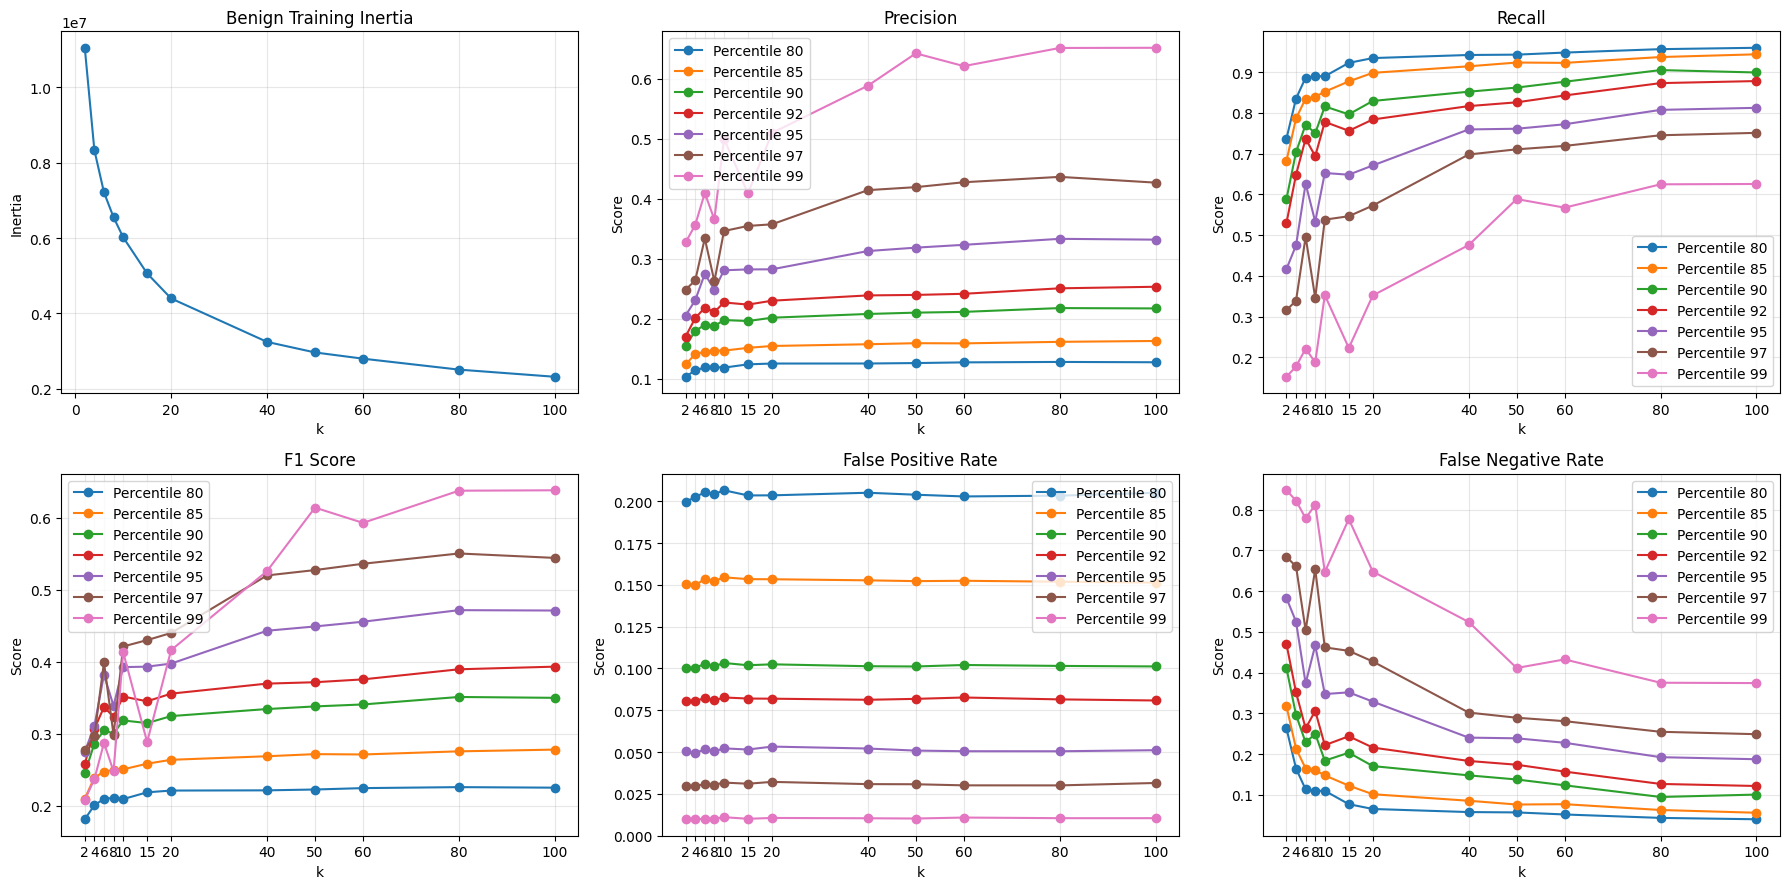

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

# Plot inertia to show how well the model fits the benign training data.
axes[0].plot(k_values, inertias, marker="o")
axes[0].set(title="Benign Training Inertia", xlabel="k", ylabel="Inertia")
axes[0].grid(alpha=0.3)

# Plot each metric for every threshold percentile.
for axis, metric, title in zip(
    axes[1:],
    ["precision", "recall", "f1", "fpr", "fnr"],
    ["Precision", "Recall", "F1 Score", "False Positive Rate", "False Negative Rate"],
):
    for percentile in threshold_percentiles:
        subset = kmeans_results_df[
            kmeans_results_df["threshold_percentile"] == percentile
        ].sort_values("k")
        axis.plot(
            subset["k"], subset[metric], marker="o", label=f"Percentile {percentile}"
        )
    axis.set(title=title, xlabel="k", ylabel="Score")
    axis.set_xticks(k_values)
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

# Autoencoders (high-recall alert generator)

### Autoencoders Hyperparameters Tuning
- Hyperparameters:
    - bottleneck_size: number of neurons in the last layer of encoding
    - Threshold_percentile: distance cutoff for classifying a sample as anomalous

- Model selection uses validation results 
    - recall >= 0.9 and FPR <= 0.15
    - if non qualify
    - keep configuration with FPR <= 0.15

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                             roc_auc_score, average_precision_score)

keras.utils.set_random_seed(Seed)

bottleneck_sizes = [2, 4, 8, 16, 32, 64]
threshold_percentiles = [80, 85, 90, 92, 95, 97, 99]

# Fit the autoencoder only on benign training features.
X_benign_train_ae = X_train_scaled[benign_train_mask].astype(np.float32)
X_evaluation_ae = X_validation_scaled.astype(np.float32)
y_evaluation_ae = y_validation
y_attack_ae = y_validation[y_validation != "benign"]
true_attack_ae = y_evaluation_ae != "benign"

input_dim = X_benign_train_ae.shape[1]
autoencoder_models = {}
ae_results = []

for bottleneck_size in bottleneck_sizes:
    keras.backend.clear_session()
    keras.utils.set_random_seed(Seed)

    inputs = keras.Input(shape=(input_dim,))
    encoded = keras.layers.Dense(64, activation="relu")(inputs)
    bottleneck = keras.layers.Dense(
        bottleneck_size, activation="relu", name="bottleneck"
    )(encoded)
    decoded = keras.layers.Dense(64, activation="relu")(bottleneck)
    outputs = keras.layers.Dense(input_dim)(decoded)
    autoencoder = keras.Model(inputs, outputs, name=f"autoencoder_{bottleneck_size}")
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    history = autoencoder.fit(
        X_benign_train_ae,
        X_benign_train_ae,
        epochs=50,
        batch_size=512,
        validation_split=0.1,
        shuffle=True,
        callbacks=[early_stopping],
        verbose=0,
    )
    autoencoder_models[bottleneck_size] = autoencoder
    print(f"Bottleneck {bottleneck_size}: trained for {len(history.history['loss'])} epochs")

    train_reconstruction = autoencoder.predict(X_benign_train_ae, verbose=0)
    train_errors = np.mean(
        (X_benign_train_ae - train_reconstruction) ** 2, axis=1
    )
    evaluation_reconstruction = autoencoder.predict(X_evaluation_ae, verbose=0)
    evaluation_errors = np.mean(
        (X_evaluation_ae - evaluation_reconstruction) ** 2, axis=1
    )

    for percentile in threshold_percentiles:
        threshold = np.percentile(train_errors, percentile)
        predicted_attack = evaluation_errors > threshold

        precision = precision_score(
            true_attack_ae, predicted_attack, zero_division=0
        )
        f1 = f1_score(true_attack_ae, predicted_attack, zero_division=0)
        recall = recall_score(true_attack_ae, predicted_attack, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(
            true_attack_ae, predicted_attack, labels=[False, True]
        ).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        fnr = fn / (fn + tp) if (fn + tp) else 0.0

        result = {
            "bottleneck_size": bottleneck_size,
            "threshold_percentile": percentile,
            "threshold": threshold,
            "precision": precision,
            "f1": f1,
            "recall": recall,
            "fpr": fpr,
            "fnr": fnr,
        }
        ae_results.append(result)

        print(
            f"bottleneck={bottleneck_size}, percentile={percentile}: "
            f"Precision={precision:.4f}, Recall={recall:.4f}, "
            f"F1={f1:.4f}"
        )
        print("  Confusion matrix [[TP, FP], [FN, TN]]:")
        print("  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]")
        print(np.array([[tp, fp], [fn, tn]]))
        for attack in sorted(np.unique(y_attack_ae)):
            attack_mask = y_evaluation_ae == attack
            detection_rate = predicted_attack[attack_mask].mean()
            print(f"  {attack} detection rate: {detection_rate:.4f}")

ae_results_df = pd.DataFrame(ae_results)
display(
    ae_results_df.sort_values("fnr", ascending=True).reset_index(drop=True)
)

# Select on validation data: prioritize recall, then control false alarms.
eligible_ae = ae_results_df[
    (ae_results_df["recall"] >= 0.90) & (ae_results_df["fpr"] <= 0.15)
]
if eligible_ae.empty:
    eligible_ae = ae_results_df[ae_results_df["fpr"] <= 0.15]
if eligible_ae.empty:
    eligible_ae = ae_results_df
best_ae_config = eligible_ae.sort_values(
    ["fnr", "fpr", "f1"], ascending=[True, True, False]
).iloc[0]
best_bottleneck_size = int(best_ae_config["bottleneck_size"])
best_ae_percentile = int(best_ae_config["threshold_percentile"])
best_autoencoder = autoencoder_models[best_bottleneck_size]
best_ae_threshold = float(best_ae_config["threshold"])

X_test_ae = X_test_scaled.astype(np.float32)
ae_test_reconstruction = best_autoencoder.predict(X_test_ae, verbose=0)
ae_test_scores = np.mean((X_test_ae - ae_test_reconstruction) ** 2, axis=1)
ae_test_predictions = ae_test_scores > best_ae_threshold
ae_test_truth = y_test != "benign"
ae_test_precision = precision_score(ae_test_truth, ae_test_predictions, zero_division=0)
ae_test_recall = recall_score(ae_test_truth, ae_test_predictions, zero_division=0)
ae_test_f1 = f1_score(ae_test_truth, ae_test_predictions, zero_division=0)
ae_tn, ae_fp, ae_fn, ae_tp = confusion_matrix(
    ae_test_truth, ae_test_predictions, labels=[False, True]
).ravel()
ae_test_fpr = ae_fp / (ae_fp + ae_tn)
ae_test_fnr = ae_fn / (ae_fn + ae_tp)
ae_test_roc_auc = roc_auc_score(ae_test_truth, ae_test_scores)
ae_test_pr_auc = average_precision_score(ae_test_truth, ae_test_scores)
print(
    f"Final autoencoder test: bottleneck={best_bottleneck_size}, "
    f"percentile={best_ae_percentile}, Precision={ae_test_precision:.4f}, "
    f"Recall={ae_test_recall:.4f}, F1={ae_test_f1:.4f}, "
    f"FPR={ae_test_fpr:.4f}, FNR={ae_test_fnr:.4f}, "
    f"ROC-AUC={ae_test_roc_auc:.4f}, PR-AUC={ae_test_pr_auc:.4f}"
)
print(np.array([[ae_tp, ae_fp], [ae_fn, ae_tn]]))
for attack in sorted(np.unique(y_test[y_test != "benign"])):
    attack_mask = y_test == attack
    print(f"  {attack} detection rate: {ae_test_predictions[attack_mask].mean():.4f}")

autoencoder_alerts_df = pd.DataFrame({
    "packet_id": packet_ids.iloc[index_test].to_numpy(),
    "true_label": y_test,
    "anomaly_score": ae_test_scores,
    "alert": ae_test_predictions,
})
autoencoder_alerts_df = autoencoder_alerts_df[
    autoencoder_alerts_df["alert"]
].reset_index(drop=True)

Bottleneck 2: trained for 50 epochs


bottleneck=2, percentile=80: Precision=0.1273, Recall=0.9453, F1=0.2244
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1123  7699]
 [   65 30301]]
  brute_force detection rate: 0.9747
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.7773
  dos detection rate: 1.0000
  xss detection rate: 0.9748
bottleneck=2, percentile=85: Precision=0.1573, Recall=0.9184, F1=0.2686
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1091  5844]
 [   97 32156]]
  brute_force detection rate: 0.9578
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.7101
  dos detection rate: 1.0000
  xss detection rate: 0.9244
bottleneck=2, percentile=90: Precision=0.2049, Recall=0.8535, F1=0.3305
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1014  3934]
 [  174 34066]]
  brute_force detection rate: 0.890

Bottleneck 4: trained for 46 epochs


bottleneck=4, percentile=80: Precision=0.1278, Recall=0.9646, F1=0.2258
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1146  7818]
 [   42 30182]]
  brute_force detection rate: 0.9873
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.8403
  dos detection rate: 1.0000
  xss detection rate: 0.9958
bottleneck=4, percentile=85: Precision=0.1608, Recall=0.9503, F1=0.2751
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1129  5890]
 [   59 32110]]
  brute_force detection rate: 0.9873
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.7815
  dos detection rate: 1.0000
  xss detection rate: 0.9832
bottleneck=4, percentile=90: Precision=0.2207, Recall=0.9301, F1=0.3567
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1105  3902]
 [   83 34098]]
  brute_force detection rate: 0.978

Bottleneck 8: trained for 41 epochs


...

bottleneck=32, percentile=80: Precision=0.1307, Recall=0.9773, F1=0.2305
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1161  7724]
 [   27 30276]]
  brute_force detection rate: 1.0000
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.8950
  dos detection rate: 1.0000
  xss detection rate: 0.9916
bottleneck=32, percentile=85: Precision=0.1650, Recall=0.9672, F1=0.2819
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1149  5814]
 [   39 32186]]
  brute_force detection rate: 1.0000
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.8487
  dos detection rate: 1.0000
  xss detection rate: 0.9874
bottleneck=32, percentile=90: Precision=0.2243, Recall=0.9478, F1=0.3628
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1126  3894]
 [   62 34106]]
  brute_force detection rate: 0.

Bottleneck 64: trained for 50 epochs


bottleneck=64, percentile=80: Precision=0.1316, Recall=0.9806, F1=0.2321
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1165  7686]
 [   23 30314]]
  brute_force detection rate: 1.0000
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.9328
  dos detection rate: 1.0000
  xss detection rate: 0.9706
bottleneck=64, percentile=85: Precision=0.1652, Recall=0.9613, F1=0.2819
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1142  5771]
 [   46 32229]]
  brute_force detection rate: 0.9916
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.8824
  dos detection rate: 1.0000
  xss detection rate: 0.9328
bottleneck=64, percentile=90: Precision=0.2171, Recall=0.9192, F1=0.3512
  Confusion matrix [[TP, FP], [FN, TN]]:
  Rows: Predicted [Attack, Benign]; Columns: Actual [Attack, Benign]
[[ 1092  3938]
 [   96 34062]]
  brute_force detection rate: 0.

,bottleneck_size,threshold_percentile,threshold,precision,f1,recall,fpr,fnr
0,16,80,0.084486,0.129307,0.228532,0.982323,0.206789,0.017677
1,64,80,0.024927,0.131624,0.232095,0.980640,0.202263,0.019360
2,32,80,0.042356,0.130670,0.230517,0.977273,0.203263,0.022727
3,16,85,0.096152,0.164420,0.281413,0.975589,0.155000,0.024411
4,8,80,0.153068,0.128683,0.227237,0.970539,0.205447,0.029461
5,32,85,0.048236,0.165015,0.281929,0.967172,0.153000,0.032828
6,4,80,0.219621,0.127845,0.225768,0.964646,0.205737,0.035354
7,64,85,0.028594,0.165196,0.281941,0.961279,0.151868,0.038721
8,8,85,0.173427,0.161579,0.276516,0.957912,0.155395,0.042088
9,16,90,0.112541,0.225838,0.365505,0.957912,0.102658,0.042088


Final autoencoder test: bottleneck=16, percentile=90, Precision=0.2335, Recall=0.9596, F1=0.3756, FPR=0.0985, FNR=0.0404, ROC-AUC=0.9849, PR-AUC=0.7956
[[ 1140  3742]
 [   48 34258]]
  brute_force detection rate: 0.9874
  ddos detection rate: 1.0000
  dns_spoofing detection rate: 0.8228
  dos detection rate: 1.0000
  xss detection rate: 0.9873


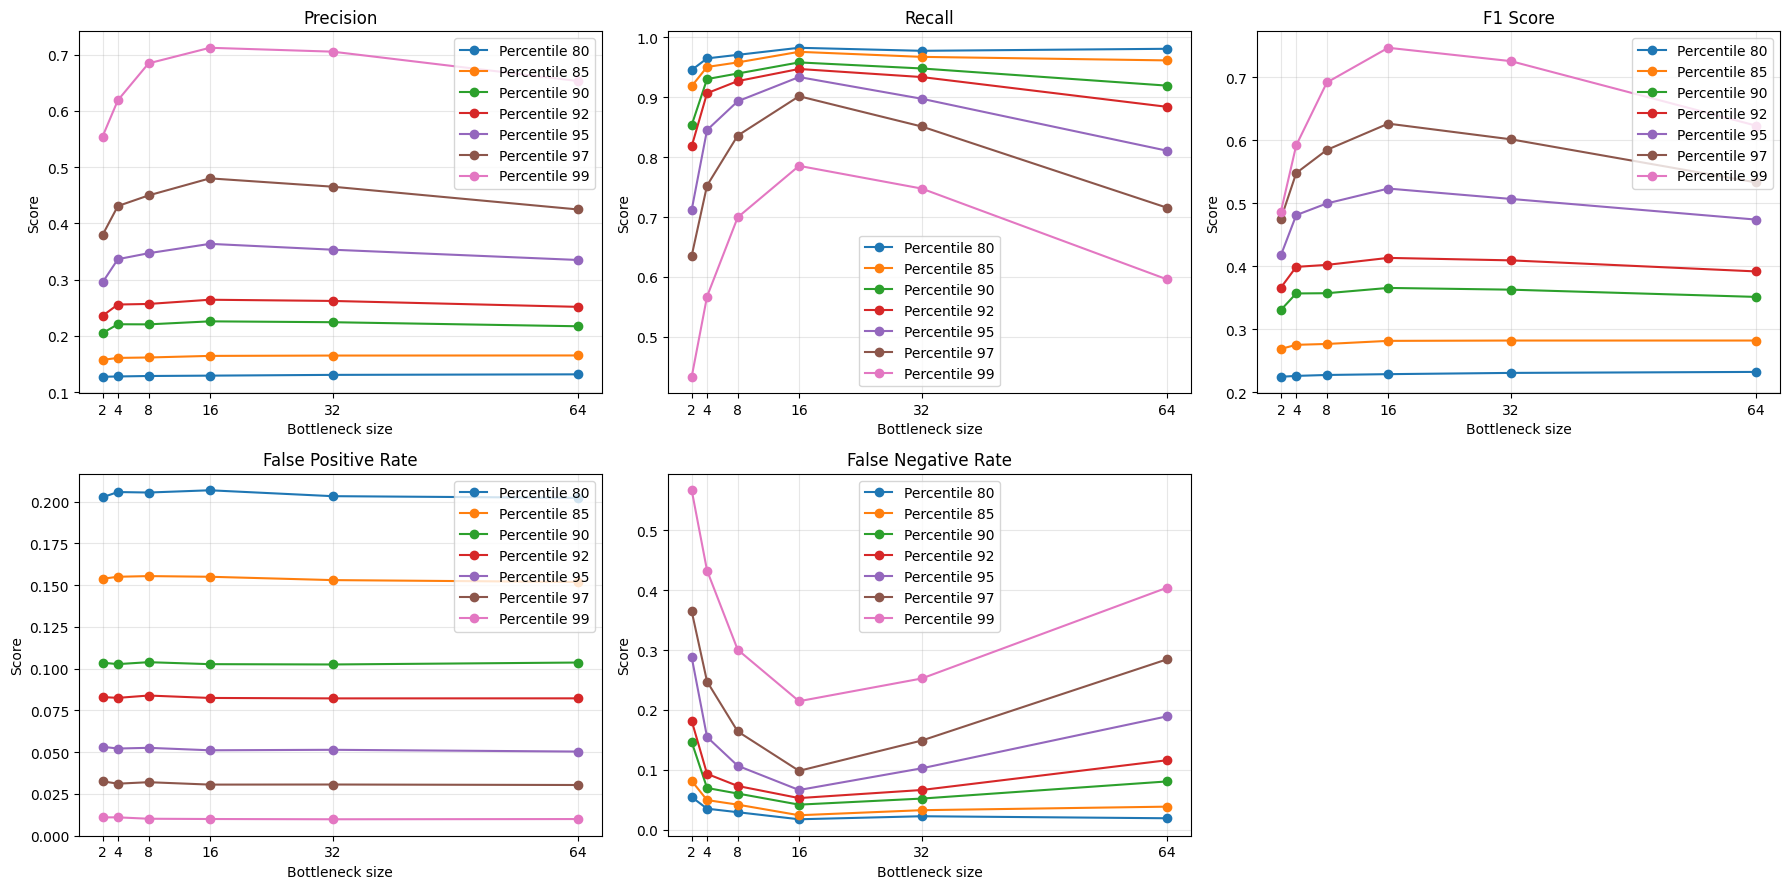

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for axis, metric, title in zip(
    axes[:5],
    ["precision", "recall", "f1", "fpr", "fnr"],
    ["Precision", "Recall", "F1 Score", "False Positive Rate", "False Negative Rate"],
):
    for percentile in threshold_percentiles:
        subset = ae_results_df[
            ae_results_df["threshold_percentile"] == percentile
        ].sort_values("bottleneck_size")
        axis.plot(
            subset["bottleneck_size"],
            subset[metric],
            marker="o",
            label=f"Percentile {percentile}",
        )
    axis.set(title=title, xlabel="Bottleneck size", ylabel="Score")
    axis.set_xticks(bottleneck_sizes)
    axis.grid(alpha=0.3)
    axis.legend()

axes[5].axis("off")
plt.tight_layout()
plt.show()

### Final Phase 2 Test Curves

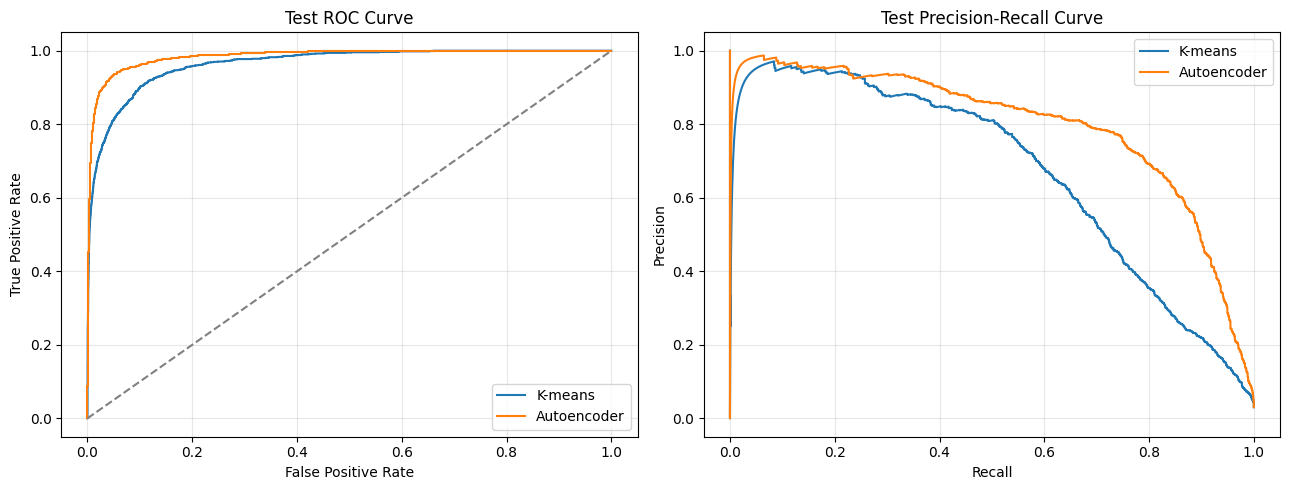

In [9]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, scores in [
    ("K-means", kmeans_test_scores),
    ("Autoencoder", ae_test_scores),
]:
    fpr_curve, tpr_curve, _ = roc_curve(ae_test_truth, scores)
    curve_precision, curve_recall, _ = precision_recall_curve(ae_test_truth, scores)
    axes[0].plot(fpr_curve, tpr_curve, label=name)
    axes[1].plot(curve_recall, curve_precision, label=name)

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(title="Test ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].set(title="Test Precision-Recall Curve", xlabel="Recall", ylabel="Precision")
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

# Export the Phase 2 Alert Data Rows
- Use autoencoder_alerts_df as the Alert for Phase 2
- Below columns are added when creating the output dataset
1. phase2_model
2. phase2_alert
3. phase2_anomaly_score
4. phase2_threshold
5. phase2_bottleneck_size
6. phase2_threshold_percentile

In [10]:
from pathlib import Path

# Export the original data rows that Phase 2 detected as alerts.
# This uses the final selected autoencoder predictions from the test partition.
phase2_alert_indices = index_test[ae_test_predictions]

phase2_alert_rows_df = pd.read_csv("../data/processed_data/packet-data/for_data.csv").iloc[
    phase2_alert_indices
].copy()
phase2_alert_rows_df["phase2_model"] = "autoencoder"
phase2_alert_rows_df["phase2_alert"] = True
phase2_alert_rows_df["phase2_anomaly_score"] = ae_test_scores[ae_test_predictions]
phase2_alert_rows_df["phase2_threshold"] = best_ae_threshold
phase2_alert_rows_df["phase2_bottleneck_size"] = best_bottleneck_size
phase2_alert_rows_df["phase2_threshold_percentile"] = best_ae_percentile

output_path = Path("../data/processed_data/packet-data/phase2_autoencoder_alert_rows_for_phase3.csv")
phase2_alert_rows_df.to_csv(output_path, index=False)

print(f"Exported {len(phase2_alert_rows_df)} Phase 2 autoencoder alert rows")
print(f"Saved to: {output_path}")
display(phase2_alert_rows_df.head())

Exported 4882 Phase 2 autoencoder alert rows
Saved to: ..\data\processed_data\packet-data\phase2_autoencoder_alert_rows_for_phase3.csv


,channel_10_count,channel_10_mean,channel_10_var,channel_1_count,channel_1_mean,channel_1_var,channel_30_count,channel_30_mean,channel_30_var,channel_5_count,...,uri_special_chars,var_p,id,label,phase2_model,phase2_alert,phase2_anomaly_score,phase2_threshold,phase2_bottleneck_size,phase2_threshold_percentile
35358,-1.248193,-0.781355,-0.565789,-0.864828,-0.753826,-0.157376,-1.509729,-0.781503,-0.579745,-1.136584,...,-0.057043,-0.302607,37111,benign,autoencoder,True,0.128688,0.112541,16,90
114823,-1.581537,-0.428530,0.771697,-1.311927,-0.421008,-1.431741,-1.826406,-0.432019,0.786877,-1.494342,...,-0.057043,-0.164137,120382,benign,autoencoder,True,0.151151,0.112541,16,90
191440,1.351657,-0.558128,0.520900,0.570115,0.052831,0.882853,1.148263,-0.661538,0.448584,0.813630,...,-0.057043,0.958288,201454,ddos,autoencoder,True,0.415071,0.112541,16,90
91931,-1.386543,-0.852592,-2.031290,-1.050391,-0.821023,-1.360173,-1.047561,-0.837878,-1.235637,-1.285067,...,-0.057043,-1.578392,96351,benign,autoencoder,True,0.118626,0.112541,16,90
127014,-0.474190,-0.891753,-2.118489,-0.864828,-0.857964,-1.431741,-0.102752,-0.890855,-2.169939,-0.569551,...,-0.057043,-2.460469,133183,benign,autoencoder,True,0.134303,0.112541,16,90
